In [80]:
import numpy as np
import pandas as pd
import openpyxl

In [83]:
practical_invest = openpyxl.load_workbook("practical_invest.xlsx")

In [84]:
date_list = practical_invest.sheetnames
del date_list[-3:]
date_list.insert(0, "20221108")
date_list.insert(0, "20221007")
date_list.append("20240708")
date_list

['20221007',
 '20221108',
 '20221207',
 '20230109',
 '20230208',
 '20230306',
 '20230407',
 '20230508',
 '20230608',
 '20230707',
 '20230808',
 '20230907',
 '20231006',
 '20231107',
 '20231207',
 '20240109',
 '20240205',
 '20240314',
 '20240409',
 '20240507',
 '20240607',
 '20240708',
 '20240807',
 '20240909',
 '20241008',
 '20241107',
 '20241209',
 '20250106',
 '20250207',
 '20250307',
 '20250408',
 '20250507',
 '20240708']

In [20]:
from datetime import datetime
invest_date = [datetime.strptime(date, "%Y%m%d").date() for date in date_list]
invest_date

[datetime.date(2022, 10, 7),
 datetime.date(2022, 11, 8),
 datetime.date(2022, 12, 7),
 datetime.date(2023, 1, 9),
 datetime.date(2023, 2, 8),
 datetime.date(2023, 3, 6),
 datetime.date(2023, 4, 7),
 datetime.date(2023, 5, 8),
 datetime.date(2023, 6, 8),
 datetime.date(2023, 7, 7),
 datetime.date(2023, 8, 8),
 datetime.date(2023, 9, 7),
 datetime.date(2023, 10, 6),
 datetime.date(2023, 11, 7),
 datetime.date(2023, 12, 7),
 datetime.date(2024, 1, 9),
 datetime.date(2024, 2, 5),
 datetime.date(2024, 3, 14),
 datetime.date(2024, 4, 9),
 datetime.date(2024, 5, 7),
 datetime.date(2024, 6, 7),
 datetime.date(2024, 7, 8),
 datetime.date(2024, 8, 7),
 datetime.date(2024, 9, 9),
 datetime.date(2024, 10, 8),
 datetime.date(2024, 11, 7),
 datetime.date(2024, 12, 9),
 datetime.date(2025, 1, 6),
 datetime.date(2025, 2, 7),
 datetime.date(2025, 3, 7),
 datetime.date(2025, 4, 8),
 datetime.date(2025, 5, 7),
 datetime.date(2025, 7, 8)]

In [72]:
data_0050 = pd.read_csv("0050TW_OHLC.csv")
data_0050

,Price,Close,High,Low,Open,Volume
0,Ticker,0050.TW,0050.TW,0050.TW,0050.TW,0050.TW
1,Date,NaN,NaN,NaN,NaN,NaN
2,2022-01-03,35.56898880004883,35.799801470544544,35.471807249384284,35.471807249384284,27136808
3,2022-01-04,36.34646224975586,36.34646224975586,35.884840537063205,35.884840537063205,38537760
4,2022-01-05,36.27357482910156,36.577271866004224,36.22498404464498,36.46794167416711,45626404
...,...,...,...,...,...,...
863,2025-07-25,50.900001525878906,51.099998474121094,50.79999923706055,51.0,38620389
864,2025-07-28,51.04999923706055,51.400001525878906,50.900001525878906,51.20000076293945,52312766
865,2025-07-29,50.45000076293945,51.04999923706055,50.25,51.04999923706055,102624231
866,2025-07-30,51.0,51.099998474121094,50.650001525878906,50.79999923706055,82807206


In [73]:
data_0050 = data_0050.drop([0, 1])
data_0050.rename(columns={'Price': 'Date'}, inplace=True)

data_0050["Convert_Date"] = [datetime.strptime(date, "%Y-%m-%d").date() for date in data_0050["Date"]]
data_0050.index = data_0050['Convert_Date']

data_0050['Close'] = data_0050['Close'].astype(float).round(2)

data_0050

,Date,Close,High,Low,Open,Volume,Convert_Date
Convert_Date,,,,,,,
2022-01-03,2022-01-03,35.57,35.799801470544544,35.471807249384284,35.471807249384284,27136808,2022-01-03
2022-01-04,2022-01-04,36.35,36.34646224975586,35.884840537063205,35.884840537063205,38537760,2022-01-04
2022-01-05,2022-01-05,36.27,36.577271866004224,36.22498404464498,36.46794167416711,45626404,2022-01-05
2022-01-06,2022-01-06,35.93,36.139941336711246,35.714765556279346,36.03061116319076,34484932,2022-01-06
2022-01-07,2022-01-07,35.62,36.200680962465256,35.593286986584964,36.0306113906665,27956496,2022-01-07
...,...,...,...,...,...,...,...
2025-07-25,2025-07-25,50.90,51.099998474121094,50.79999923706055,51.0,38620389,2025-07-25
2025-07-28,2025-07-28,51.05,51.400001525878906,50.900001525878906,51.20000076293945,52312766,2025-07-28
2025-07-29,2025-07-29,50.45,51.04999923706055,50.25,51.04999923706055,102624231,2025-07-29


In [74]:
simulation_data = data_0050.loc[data_0050.index.intersection(invest_date), ["Close"]]

simulation_data["Amount"] = np.round(10000 / simulation_data["Close"], 0) - 2     # minus 2 for the error value

transaction_fee_ratio = 0.001425
simulation_data["Transaction Fee"] = np.round(simulation_data["Close"] * simulation_data["Amount"] * transaction_fee_ratio, 0)

simulation_data["Total Invest"] = np.round(simulation_data["Close"] * simulation_data["Amount"]) + simulation_data["Transaction Fee"]

simulation_data["Accumulated Amount"] = np.cumsum(simulation_data["Amount"].iloc[::1])
simulation_data["Accumulated Cost"] = np.cumsum(simulation_data["Total Invest"].iloc[::1])
simulation_data["Total Value"] = simulation_data["Close"] * simulation_data["Accumulated Amount"]

simulation_data

,Close,Amount,Transaction Fee,Total Invest,Accumulated Amount,Accumulated Cost,Total Value
Convert_Date,,,,,,,
2022-10-07,25.85,385.0,14.0,9966.0,385.0,9966.0,9952.25
2022-11-08,24.73,402.0,14.0,9955.0,787.0,19921.0,19462.51
2022-12-07,27.90,356.0,14.0,9946.0,1143.0,29867.0,31889.70
2023-01-09,28.19,353.0,14.0,9965.0,1496.0,39832.0,42172.24
2023-02-08,29.42,338.0,14.0,9958.0,1834.0,49790.0,53956.28
2023-03-06,29.33,339.0,14.0,9957.0,2173.0,59747.0,63734.09
2023-04-07,29.46,337.0,14.0,9942.0,2510.0,69689.0,73944.60
2023-05-08,28.86,345.0,14.0,9971.0,2855.0,79660.0,82395.30
2023-06-08,30.88,322.0,14.0,9957.0,3177.0,89617.0,98105.76


In [75]:
sell_price = float(data_0050.iat[-1, 1])  #2025-07-31
total_value = float(sell_price * simulation_data.iat[-1, 4])
total_cost = sum(simulation_data["Total Invest"])
tax_fee_ratio = 0.003
sell_fee = np.round(total_value * (transaction_fee_ratio + tax_fee_ratio), 2)

In [76]:
simulation_data = pd.concat([simulation_data, pd.DataFrame({'Close': sell_price,
                                                            'Amount': simulation_data.iat[-1, 1],
                                                            'Transaction Fee': sell_fee,
                                                            'Total Invest': 0,
                                                            'Accumulated Amount': simulation_data.iat[-1, 4], 
                                                            'Accumulated Cost': simulation_data.iat[-1, 5], 
                                                            'Total Value': sell_price * simulation_data.iat[-1, 4] - sell_fee},
                                                        index = [datetime.strptime("2025-07-31", "%Y-%m-%d").date()])])
simulation_data

,Close,Amount,Transaction Fee,Total Invest,Accumulated Amount,Accumulated Cost,Total Value
2022-10-07,25.85,385.0,14.00,9966.0,385.0,9966.0,9952.25
2022-11-08,24.73,402.0,14.00,9955.0,787.0,19921.0,19462.51
2022-12-07,27.90,356.0,14.00,9946.0,1143.0,29867.0,31889.70
2023-01-09,28.19,353.0,14.00,9965.0,1496.0,39832.0,42172.24
2023-02-08,29.42,338.0,14.00,9958.0,1834.0,49790.0,53956.28
2023-03-06,29.33,339.0,14.00,9957.0,2173.0,59747.0,63734.09
2023-04-07,29.46,337.0,14.00,9942.0,2510.0,69689.0,73944.60
2023-05-08,28.86,345.0,14.00,9971.0,2855.0,79660.0,82395.30
2023-06-08,30.88,322.0,14.00,9957.0,3177.0,89617.0,98105.76
2023-07-07,31.09,320.0,14.00,9963.0,3497.0,99580.0,108721.73


In [77]:
simulation_data['Return'] = np.round(simulation_data['Total Value'] / simulation_data['Accumulated Cost'], 4)
simulation_data

,Close,Amount,Transaction Fee,Total Invest,Accumulated Amount,Accumulated Cost,Total Value,Return
2022-10-07,25.85,385.0,14.00,9966.0,385.0,9966.0,9952.25,0.9986
2022-11-08,24.73,402.0,14.00,9955.0,787.0,19921.0,19462.51,0.9770
2022-12-07,27.90,356.0,14.00,9946.0,1143.0,29867.0,31889.70,1.0677
2023-01-09,28.19,353.0,14.00,9965.0,1496.0,39832.0,42172.24,1.0588
2023-02-08,29.42,338.0,14.00,9958.0,1834.0,49790.0,53956.28,1.0837
2023-03-06,29.33,339.0,14.00,9957.0,2173.0,59747.0,63734.09,1.0667
2023-04-07,29.46,337.0,14.00,9942.0,2510.0,69689.0,73944.60,1.0611
2023-05-08,28.86,345.0,14.00,9971.0,2855.0,79660.0,82395.30,1.0343
2023-06-08,30.88,322.0,14.00,9957.0,3177.0,89617.0,98105.76,1.0947
2023-07-07,31.09,320.0,14.00,9963.0,3497.0,99580.0,108721.73,1.0918


In [98]:
actual_invest_data = pd.read_excel('practical_invest.xlsx', sheet_name="Summary")
actual_invest_data["Convert_Date"] = [datetime.strptime(date, "%Y%m%d").date() for date in actual_invest_data["Date"].apply(str)]
actual_invest_data

,Date,Return,Convert_Date
0,20221207,1.0148,2022-12-07
1,20230109,0.9995,2023-01-09
2,20230208,1.0521,2023-02-08
3,20230306,1.0588,2023-03-06
4,20230407,1.0308,2023-04-07
5,20230508,1.0598,2023-05-08
6,20230608,1.1140,2023-06-08
7,20230707,1.1277,2023-07-07
8,20230808,1.2064,2023-08-08
9,20230907,1.2113,2023-09-07


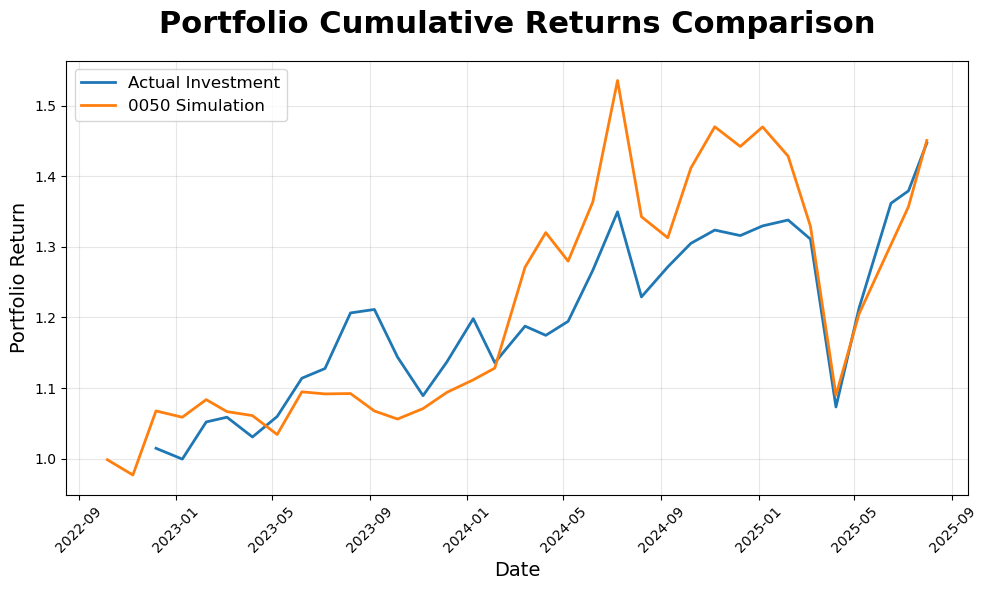

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot both portfolios
plt.plot(actual_invest_data['Convert_Date'], actual_invest_data['Return'], 
         label='Actual Investment', linewidth=2)
plt.plot(simulation_data.index, simulation_data['Return'], 
         label='0050 Simulation', linewidth=2)

# Customize the plot
plt.title('Portfolio Cumulative Returns Comparison', fontsize=22, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Portfolio Return', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()